<a href="https://colab.research.google.com/github/momensaleh193-png/NTI-ML-/blob/main/gas_sensor_eda_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('gas_sensor_array_drift_dataset.csv')
print("number of rows and columns  :", df.shape)
df.head()


number of rows and columns  : (13910, 131)


,batch,gas_id,gas_name,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128
0,1,1,Ethanol,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,1,1,Ethanol,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,...,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,1,1,Ethanol,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,...,-2.384784,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370
3,1,1,Ethanol,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957
4,1,1,Ethanol,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


In [42]:

!pip install -q ydata-profiling

from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Gas Sensor Array Drift - تقرير شامل", explorative=True, minimal=True)


profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 131/131 [00:04<00:00, 27.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [43]:
feature_cols = [c for c in df.columns if c.startswith('feature_')]
print(" number of columns:", len(feature_cols))


 number of columns: 128


In [44]:
from sklearn.impute import SimpleImputer

missing = df[feature_cols].isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("no missing values  ")
else:
    print(" missing values are :")
    print(missing)
    imputer = SimpleImputer(strategy='median')
    df[feature_cols] = imputer.fit_transform(df[feature_cols])



no missing values  


In [45]:
n_duplicates = df.duplicated().sum()
print("  duplicated rows :", n_duplicates)



  duplicated rows : 0


In [46]:
print(df.dtypes.value_counts())

for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

new_missing = df[feature_cols].isnull().sum().sum()
print("new missing values  :", new_missing)



float64    128
int64        2
object       1
Name: count, dtype: int64
new missing values  : 0


In [47]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02, random_state=42)
outlier_flags = iso.fit_predict(df[feature_cols])

df['is_outlier'] = outlier_flags  # -1 = شاذ, 1 = عادي
n_outliers = (df['is_outlier'] == -1).sum()
print("  outlier rows  :", n_outliers)


  outlier rows  : 279


/tmp/ipykernel_3784/1503475734.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_outlier'] = outlier_flags  # -1 = شاذ, 1 = عادي


In [48]:
for c in feature_cols:
    lower = df[c].quantile(0.01)
    upper = df[c].quantile(0.99)
    df[c] = df[c].clip(lower=lower, upper=upper)

df = df.drop(columns=['is_outlier'])


In [49]:
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])


print(df_scaled[feature_cols].mean().round(3).head())
print(df_scaled[feature_cols].std().round(3).head())


feature_1   -0.0
feature_2    0.0
feature_3    0.0
feature_4   -0.0
feature_5    0.0
dtype: float64
feature_1    1.0
feature_2    1.0
feature_3    1.0
feature_4    1.0
feature_5    1.0
dtype: float64


In [50]:
print("  gas distribution:")
print(df['gas_name'].value_counts())

print("\n  batches:")
print(df['batch'].value_counts().sort_index())


  gas distribution:
gas_name
Acetone         3009
Ethylene        2926
Ethanol         2565
Acetaldehyde    1936
Toluene         1833
Ammonia         1641
Name: count, dtype: int64

  batches:
batch
1      445
2     1244
3     1586
4      161
5      197
6     2300
7     3613
8      294
9      470
10    3600
Name: count, dtype: int64


In [51]:
df.to_csv('gas_sensor_cleaned.csv', index=False)
df_scaled.to_csv('gas_sensor_cleaned_scaled.csv', index=False)




In [52]:
import matplotlib.pyplot as plt
import seaborn as sns


print(" number of rows and columns:", df.shape)
df.head()


 number of rows and columns: (13910, 131)


,batch,gas_id,gas_name,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128
0,1,1,Ethanol,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.848363,2.782893,-0.545079,-0.902241,-2.654529
1,1,1,Ethanol,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,...,-1.530519,-2.889309,4176.4453,4.281373,0.980205,1.628050,2.782893,-0.889333,-1.323505,-2.620467
2,1,1,Ethanol,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,...,-2.384784,-2.889309,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.620467
3,1,1,Ethanol,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.620467
4,1,1,Ethanol,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


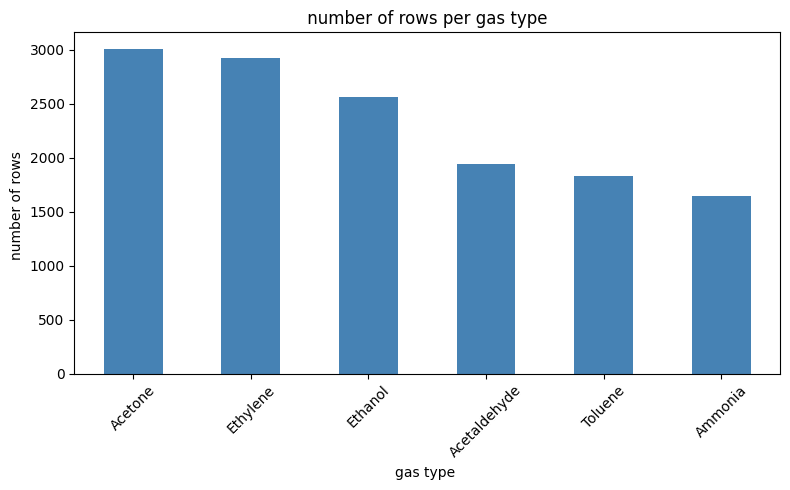

In [53]:
plt.figure(figsize=(8,5))
df['gas_name'].value_counts().plot(kind='bar', color='steelblue')
plt.title(' number of rows per gas type ')
plt.xlabel('gas type ')
plt.ylabel('number of rows ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


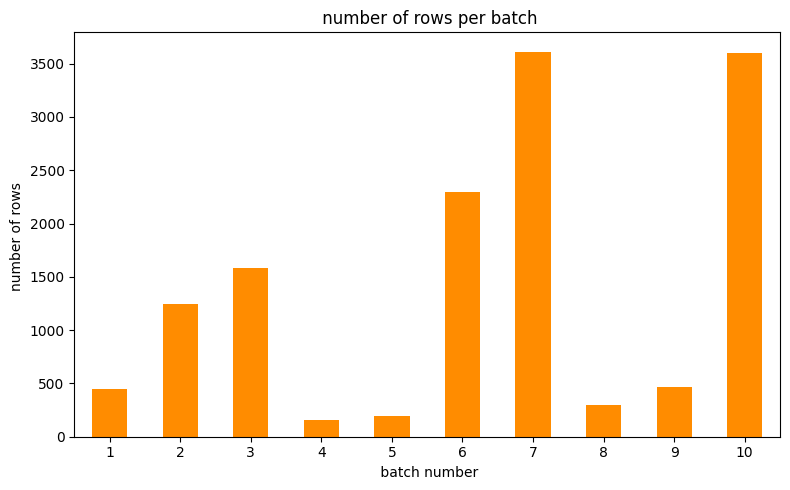

In [54]:
plt.figure(figsize=(8,5))
df['batch'].value_counts().sort_index().plot(kind='bar', color='darkorange')
plt.title(' number of rows per batch')
plt.xlabel(' batch number')
plt.ylabel('number of rows ')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


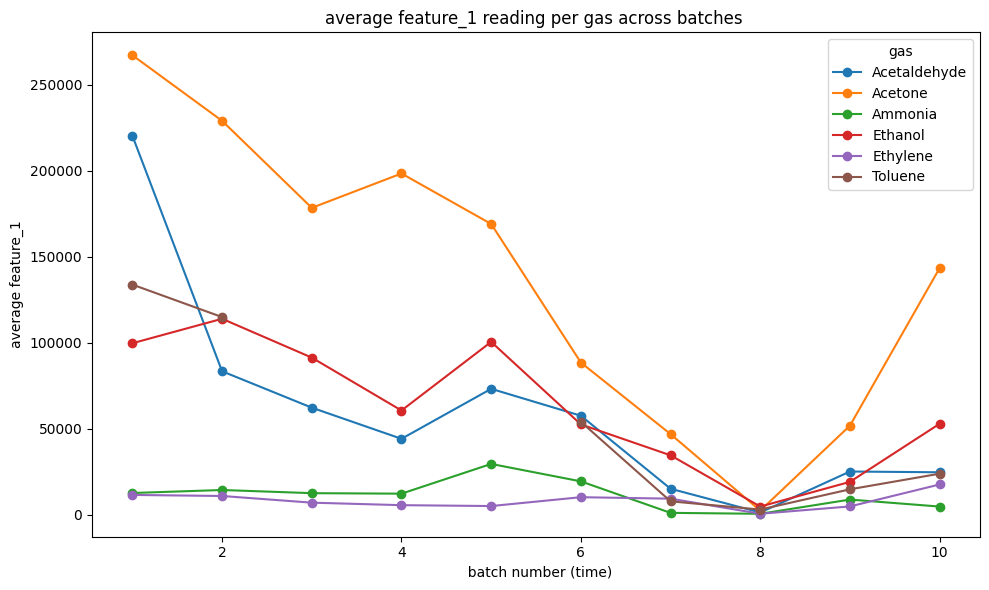

In [55]:
drift_view = df.groupby(['batch', 'gas_name'])['feature_1'].mean().unstack()

plt.figure(figsize=(10,6))
for gas in drift_view.columns:
    plt.plot(drift_view.index, drift_view[gas], marker='o', label=gas)

plt.title("average feature_1 reading per gas across batches ")
plt.xlabel('  batch number (time)')
plt.ylabel('average feature_1')
plt.legend(title='gas')
plt.tight_layout()
plt.show()


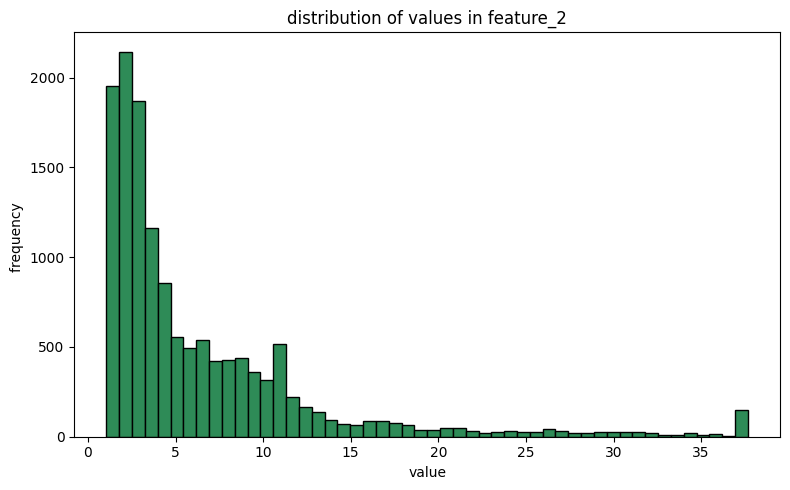

In [56]:
plt.figure(figsize=(8,5))
plt.hist(df['feature_2'], bins=50, color='seagreen', edgecolor='black')
plt.title("distribution of values in feature_2")
plt.xlabel('value')
plt.ylabel('frequency ')
plt.tight_layout()
plt.show()


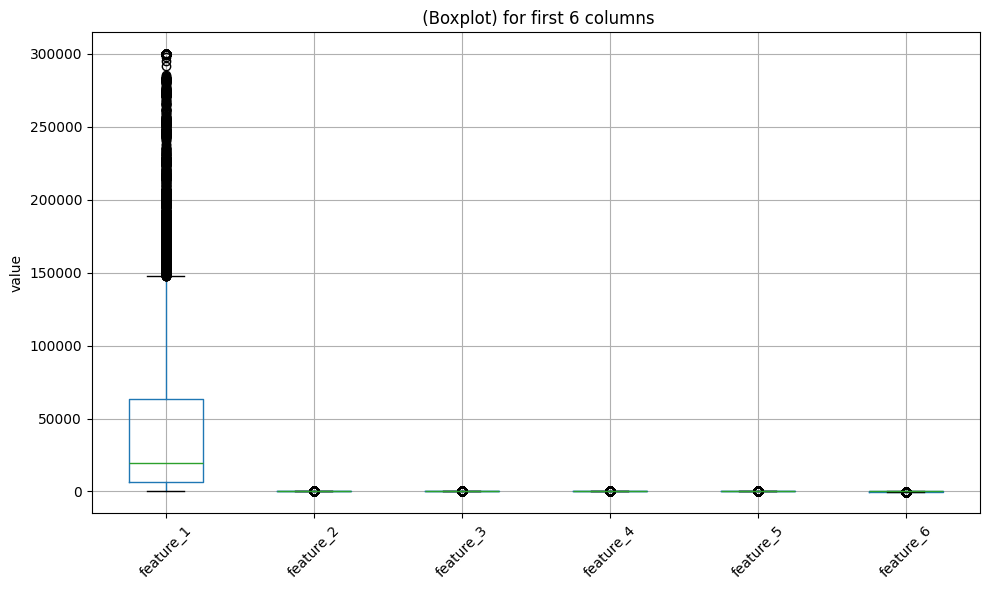

In [57]:
plt.figure(figsize=(10,6))
df[feature_cols[:6]].boxplot()
plt.title(' (Boxplot) for first 6 columns')
plt.ylabel('value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


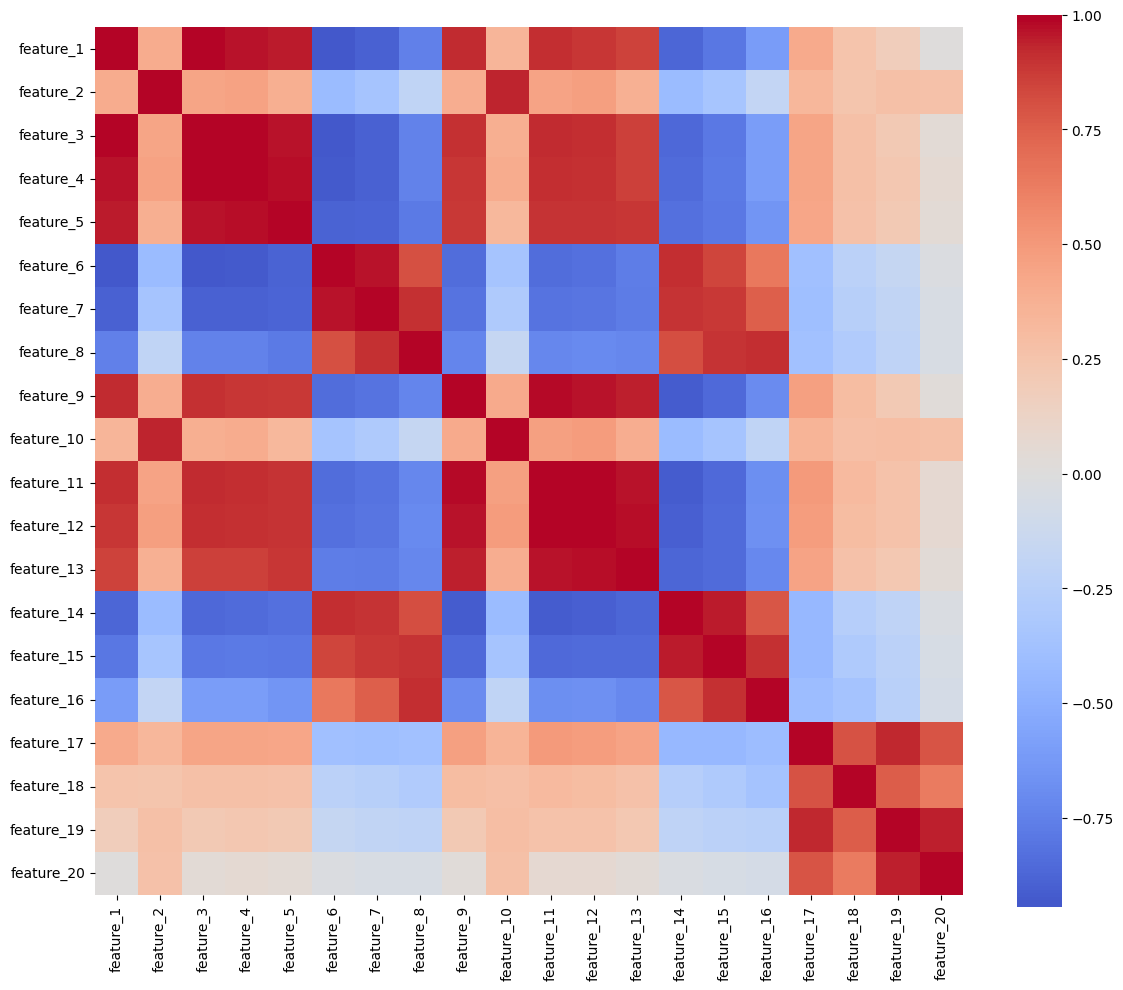

In [58]:
plt.figure(figsize=(12,10))
corr = df[feature_cols[:20]].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.tight_layout()
plt.show()


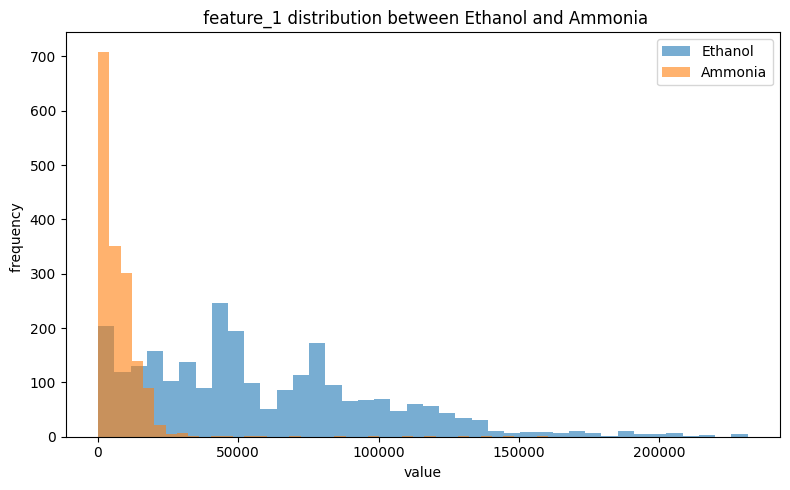

In [59]:
plt.figure(figsize=(8,5))
for gas in ['Ethanol', 'Ammonia']:
    subset = df[df['gas_name'] == gas]['feature_1']
    plt.hist(subset, bins=40, alpha=0.6, label=gas)

plt.title(' feature_1 distribution between Ethanol and Ammonia')
plt.xlabel('value')
plt.ylabel('frequency ')
plt.legend()
plt.tight_layout()
plt.show()
